<a href="https://colab.research.google.com/github/CeSaRLoPeZArTeAgA/Modelos_de_Aprendizaje_Automatico-IMCA/blob/main/Clase_4_OM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos del Aprendizaje Automatico - MMC214

---


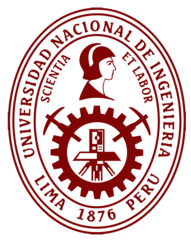

---
#REDES NEURONALES 1 - PERCEPTRON
---

In [ ]:
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
sns.set_style('darkgrid')
sns.set_context('poster')
plt.rcParams["figure.figsize"] = [20, 10]

In [ ]:
import numpy as np

In [ ]:
class Perceptron:
    """
    Create a perceptron.

    train_data: A 4x2 matrix with the input data.

    target: A 4x1 matrix with the perceptron's expected outputs

    lr: the learning rate. Defaults to 0.01

    input_nodes: the number of nodes in the input layer of the perceptron.
        Should be equal to the second dimension of train_data.
    """

    def __init__(self, train_data, target, lr=0.01, input_nodes=2):
        self.train_data = train_data
        self.target = target
        self.lr = lr
        self.input_nodes = input_nodes

        # randomly initialize the weights and set the bias to -1.
        self.w = np.random.uniform(size=self.input_nodes)
        self.b = -1

        # node_val hold the values of each node at a given point of time.
        self.node_val = np.zeros(self.input_nodes)

        # tracks how the number of consecutively correct classifications
        # changes in each iteration
        self.correct_iter = [0]

    def _gradient(self, node, exp, output):
        """
        Return the gradient for a weight.
        This is the value of delta-w.
        """
        return node * (exp - output)

    def update_weights(self, exp, output):
        """
        Update weights and bias based on their respective gradients
        """
        for i in range(self.input_nodes):
            self.w[i] += self.lr * self._gradient(self.node_val[i], exp, output)

        # the value of the bias node can be considered as being 1 and the weight between this node
        # and the output node being self.b
        self.b += self.lr * self._gradient(1, exp, output)

    def forward(self, datapoint):
        """
        One forward pass through the perceptron.
        Implementation of "wX + b".
        """
        return self.b + np.dot(self.w, datapoint)

    def classify(self, datapoint):
        """
        Return the class to which a datapoint belongs based on
        the perceptron's output for that point.
        """
        if self.forward(datapoint) >= 0:
            return 1

        return 0

    def plot(self, h=0.01):
        """
        Generate plot of input data and decision boundary.
        """
        # setting plot properties like size, theme and axis limits
        sns.set_style('darkgrid')
        plt.figure(figsize=(10, 10))

        plt.axis('scaled')
        plt.xlim(-0.1, 1.1)
        plt.ylim(-0.1, 1.1)

        colors = {
            0: "ro",
            1: "go"
        }

        for i in range(len(self.train_data)):
            plt.plot([self.train_data[i][0]],
                     [self.train_data[i][1]],
                     colors[self.target[i][0]],
                     markersize=20)

        x_range = np.arange(-0.1, 1.1, h)
        y_range = np.arange(-0.1, 1.1, h)

        # creating a mesh to plot decision boundary
        xx, yy = np.meshgrid(x_range, y_range, indexing='ij')
        Z = np.array([[self.classify([x, y]) for x in x_range] for y in y_range])

        # using the contourf function to create the plot
        plt.contourf(xx, yy, Z, colors=['red', 'green', 'green', 'blue'], alpha=0.4)


    def train(self):
        """
        Train a single layer perceptron.
        """
        # the number of consecutive correct classifications
        correct_counter = 0
        iterations = 0

        for train, target in cycle(zip(self.train_data, self.target)):
            # end if all points are correctly classified
            if correct_counter == len(self.train_data):
                break

            # a single layer perceptron can't model the xor function
            # so it'll never converge!
            if iterations > 1000:
                print("1000 iterations exceded without convergence! A single layered perceptron can't handle this problem.")
                break

            output = self.classify(train)
            self.node_val = train
            iterations += 1

            # if correctly classified, increment correct_counter
            if output == target[0]:
                correct_counter += 1
            else:
                # if incorrectly classified, update weights and reset correct_counter
                self.update_weights(target[0], output)
                correct_counter = 0

            self.correct_iter.append(correct_counter)

In [ ]:
train_data = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]])

target_xor = np.array(
    [
        [0],
        [1],
        [1],
        [0]])

target_nand = np.array(
    [
        [1],
        [1],
        [1],
        [0]])

target_or = np.array(
    [
        [0],
        [1],
        [1],
        [1]])

target_and = np.array(
    [
        [0],
        [0],
        [0],
        [1]])

In [ ]:
p_xor = Perceptron(train_data, target_xor)
p_xor.train()

1000 iterations exceded without convergence! A single layered perceptron can't handle this problem.


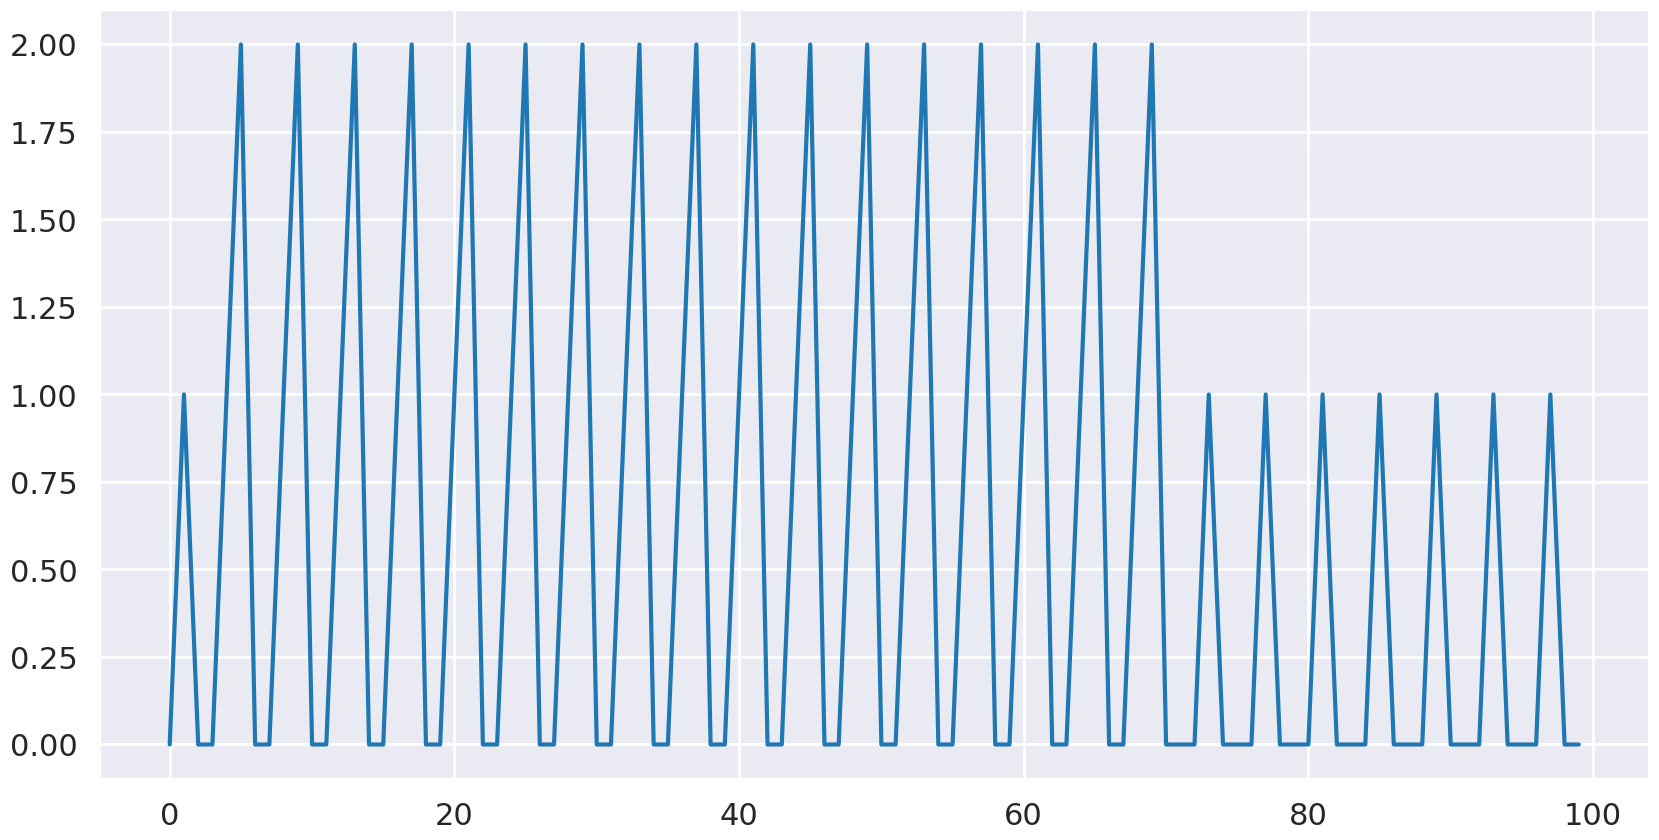

In [ ]:
plt.plot(p_xor.correct_iter[:100])

In [ ]:
p_or = Perceptron(train_data, target_or)
p_or.train()

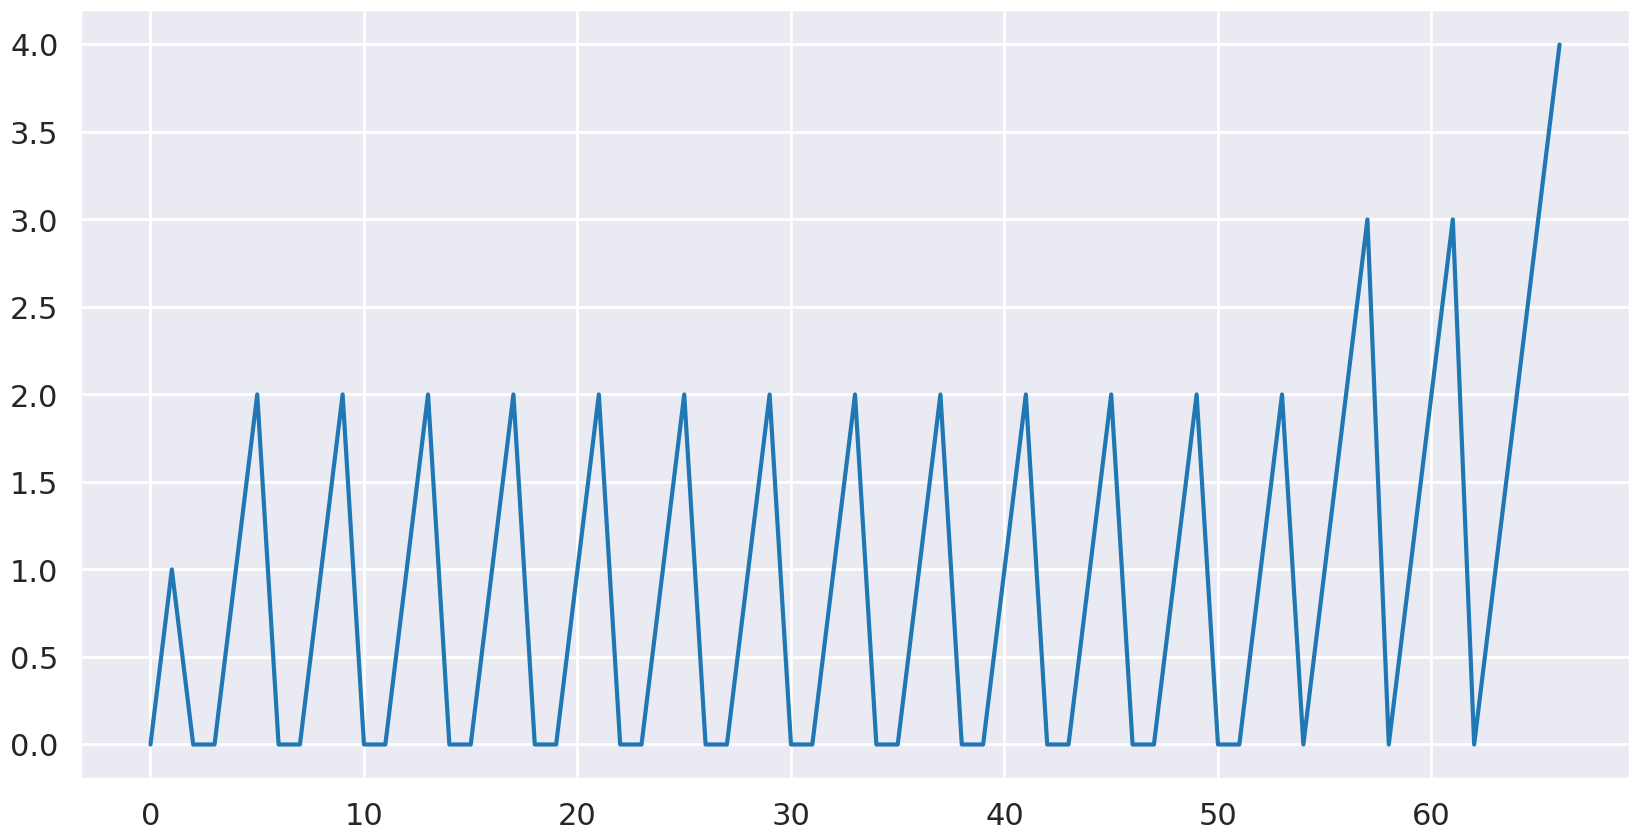

In [ ]:
plt.plot(p_or.correct_iter[:200])

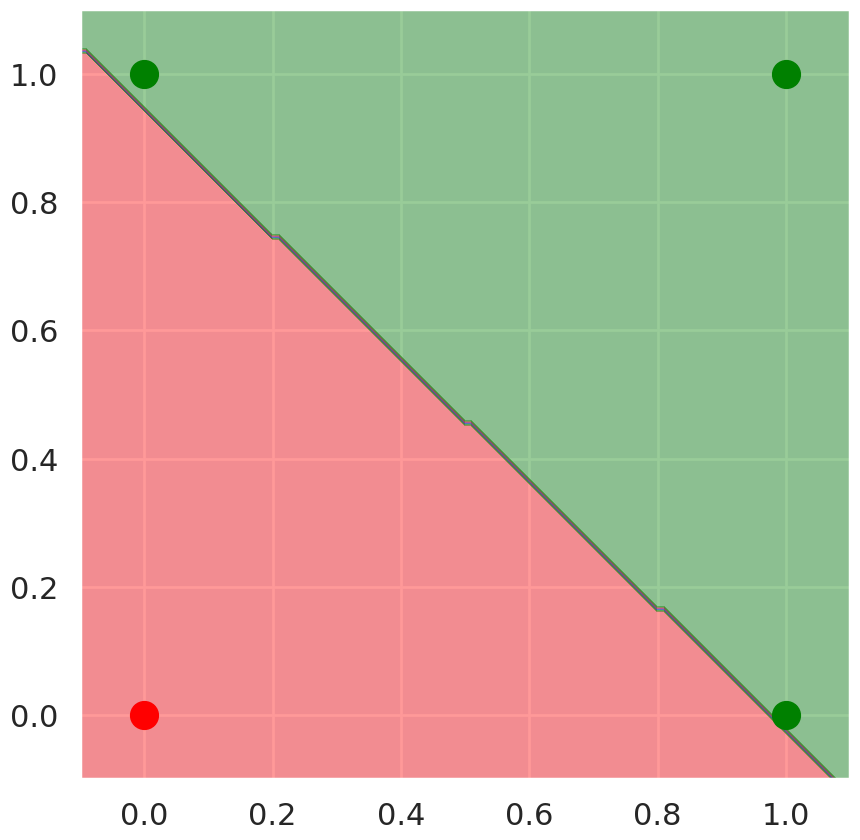

In [ ]:
p_or.plot()

In [ ]:
p_nand = Perceptron(train_data, target_nand)
p_nand.train()

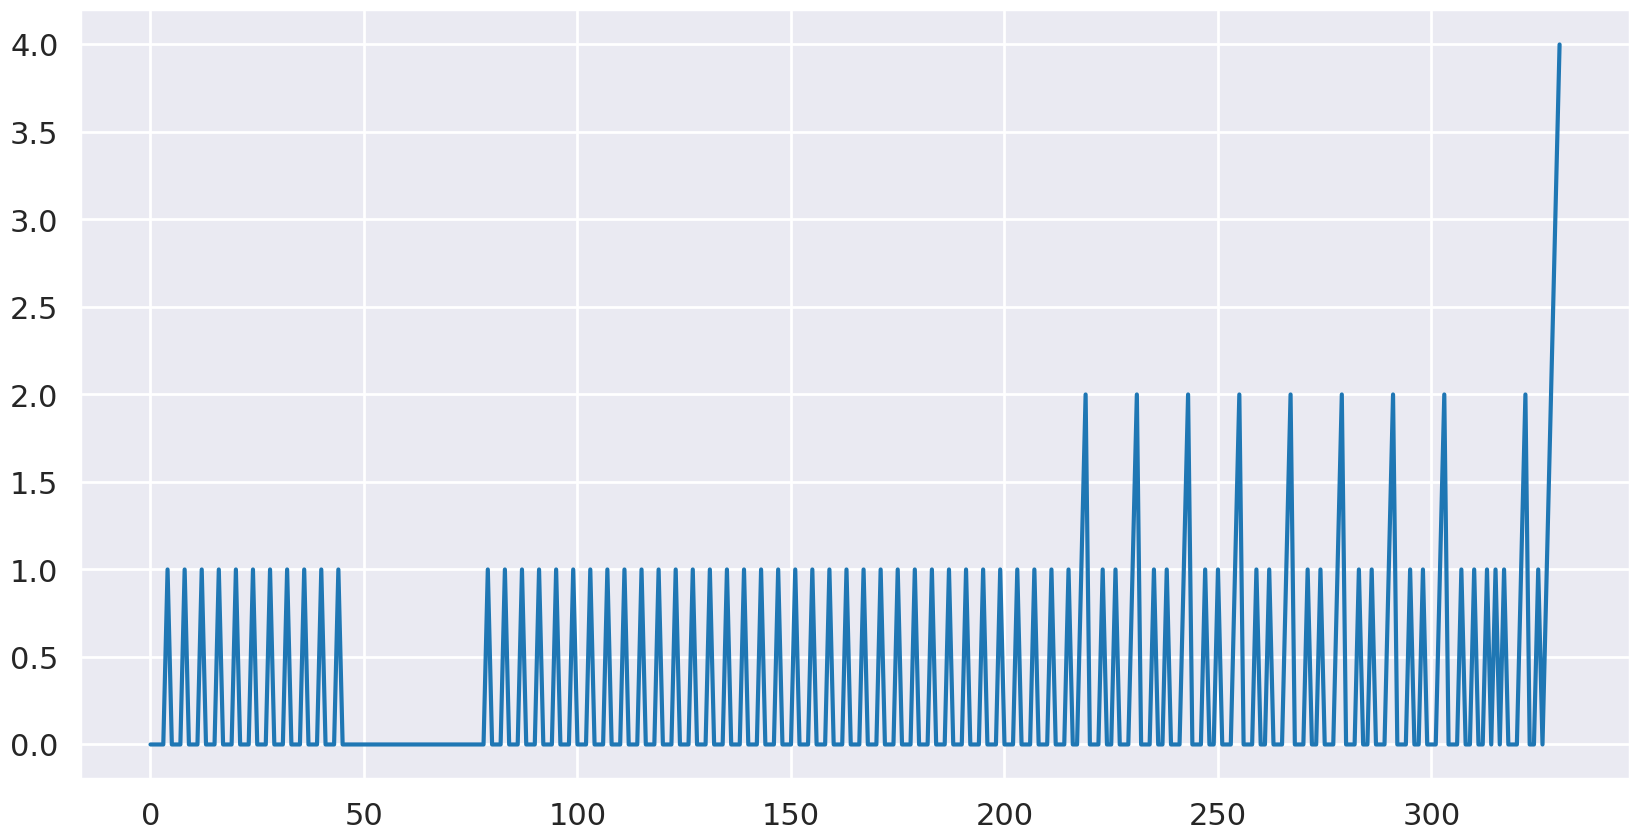

In [ ]:
plt.plot(p_nand.correct_iter[:1000])

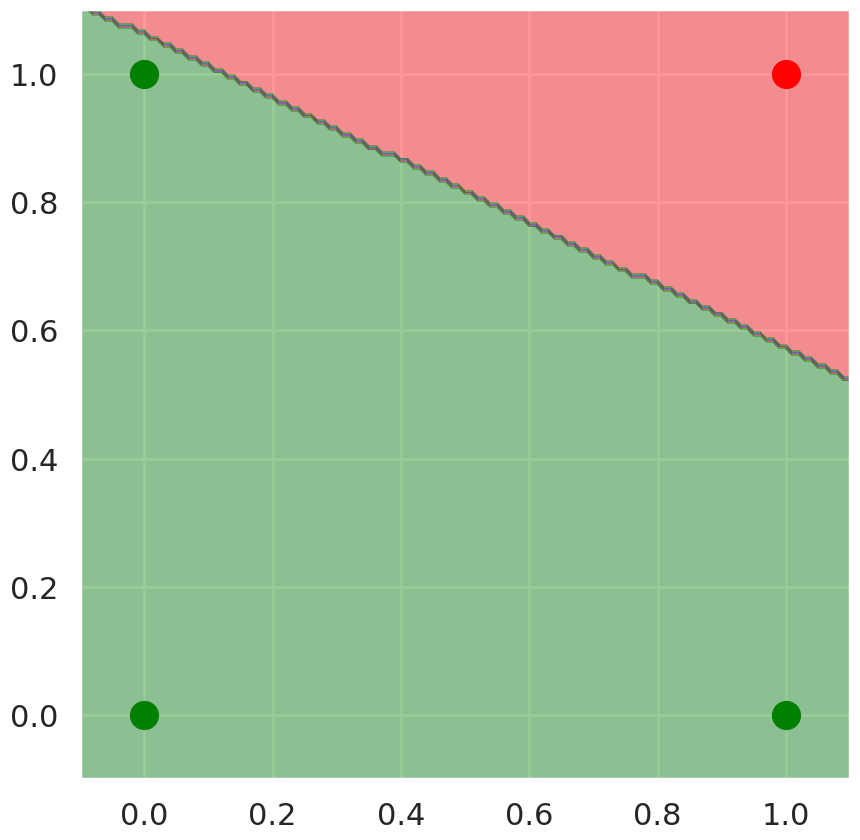

In [ ]:
p_nand.plot()

In [ ]:
p_and = Perceptron(train_data, target_and)
p_and.train()

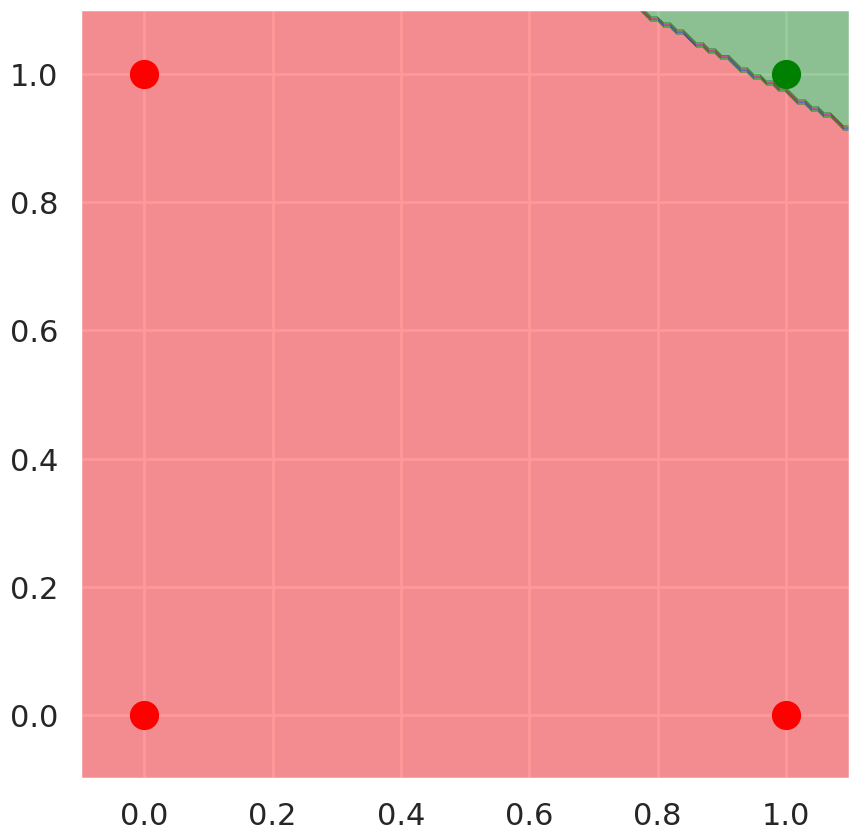

In [ ]:
p_and.plot()

In [ ]:
def XOR(x1, x2):
    """
    Return the boolean XOR of x1 and x2 by combining
    individual single-layered perceptrons
    """

    x = [x1, x2]
    p_or = Perceptron(train_data, target_or)
    p_nand = Perceptron(train_data, target_nand)
    p_and = Perceptron(train_data, target_and)

    p_or.train()
    p_nand.train()
    p_and.train()

    return p_and.classify([p_or.classify(x),
                          p_nand.classify(x)])

In [ ]:
XOR(1,1)

0

In [ ]:
class MLP:
    """
    Create a multi-layer perceptron.

    train_data: A 4x2 matrix with the input data.

    target: A 4x1 matrix with expected outputs

    lr: the learning rate. Defaults to 0.1

    num_epochs: the number of times the training data goes through the model
        while training

    num_input: the number of nodes in the input layer of the MLP.
        Should be equal to the second dimension of train_data.

    num_hidden: the number of nodes in the hidden layer of the MLP.

    num_output: the number of nodes in the output layer of the MLP.
        Should be equal to the second dimension of target.
    """
    def __init__(self, train_data, target, lr=0.1, num_epochs=100, num_input=2, num_hidden=2, num_output=1):
        self.train_data = train_data
        self.target = target
        self.lr = lr
        self.num_epochs = num_epochs

        # initialize both sets of weights and biases randomly
            # - weights_01: weights between input and hidden layer
            # - weights_12: weights between hidden and output layer
        self.weights_01 = np.random.uniform(size=(num_input, num_hidden))
        self.weights_12 = np.random.uniform(size=(num_hidden, num_output))

        # - b01: biases for the  hidden layer
        # - b12: bias for the output layer
        self.b01 = np.random.uniform(size=(1,num_hidden))
        self.b12 = np.random.uniform(size=(1,num_output))

        self.losses = []

    def update_weights(self):

        # Calculate the squared error
        loss = 0.5 * (self.target - self.output_final) ** 2
        self.losses.append(np.sum(loss))

        error_term = (self.target - self.output_final)

        # the gradient for the hidden layer weights
        grad01 = self.train_data.T @ (((error_term * self._delsigmoid(self.output_final)) * self.weights_12.T) * self._delsigmoid(self.hidden_out))

        # the gradient for the output layer weights
        grad12 = self.hidden_out.T @ (error_term * self._delsigmoid(self.output_final))

        # updating the weights by the learning rate times their gradient
        self.weights_01 += self.lr * grad01
        self.weights_12 += self.lr * grad12

        # update the biases the same way
        self.b01 += np.sum(self.lr * ((error_term * self._delsigmoid(self.output_final)) * self.weights_12.T) * self._delsigmoid(self.hidden_out), axis=0)
        self.b12 += np.sum(self.lr * error_term * self._delsigmoid(self.output_final), axis=0)

    def _sigmoid(self, x):
        """
        The sigmoid activation function.
        """
        return 1 / (1 + np.exp(-x))

    def _delsigmoid(self, x):
        """
        The first derivative of the sigmoid function wrt x
        """
        return x * (1 - x)

    def forward(self, batch):
        """
        A single forward pass through the network.
        Implementation of wX + b
        """

        self.hidden_ = np.dot(batch, self.weights_01) + self.b01
        self.hidden_out = self._sigmoid(self.hidden_)

        self.output_ = np.dot(self.hidden_out, self.weights_12) + self.b12
        self.output_final = self._sigmoid(self.output_)

        return self.output_final

    def classify(self, datapoint):
        """
        Return the class to which a datapoint belongs based on
        the perceptron's output for that point.
        """
        datapoint = np.transpose(datapoint)
        if self.forward(datapoint) >= 0.5:
            return 1

        return 0

    def plot(self, h=0.01):
        """
        Generate plot of input data and decision boundary.
        """
        # setting plot properties like size, theme and axis limits
        sns.set_style('darkgrid')
        plt.figure(figsize=(10, 10))

        plt.axis('scaled')
        plt.xlim(-0.1, 1.1)
        plt.ylim(-0.1, 1.1)

        colors = {
            0: "ro",
            1: "go"
        }

        # plotting the four datapoints
        for i in range(len(self.train_data)):
            plt.plot([self.train_data[i][0]],
                     [self.train_data[i][1]],
                     colors[self.target[i][0]],
                     markersize=20)

        x_range = np.arange(-0.1, 1.1, h)
        y_range = np.arange(-0.1, 1.1, h)

        # creating a mesh to plot decision boundary
        xx, yy = np.meshgrid(x_range, y_range, indexing='ij')
        Z = np.array([[self.classify([x, y]) for x in x_range] for y in y_range])

        # using the contourf function to create the plot
        plt.contourf(xx, yy, Z, colors=['red', 'green', 'green', 'blue'], alpha=0.4)

    def train(self):
        """
        Train an MLP. Runs through the data num_epochs number of times.
        A forward pass is done first, followed by a backward pass (backpropagation)
        where the networks parameter's are updated.
        """
        for epoch in range(self.num_epochs):

            self.forward(self.train_data)
            self.update_weights()

            if epoch % 500 == 0:
                print("Loss: ", self.losses[epoch])

In [ ]:
mlp = MLP(train_data, target_xor, 0.1, 10000)
mlp.train()

Loss:  0.5794825496722742
Loss:  0.49956357508659743
Loss:  0.49825141264405737
Loss:  0.4952298311572704
Loss:  0.4865004750536507
Loss:  0.46219716353230555
Loss:  0.4138715912041691
Loss:  0.3593716281646062
Loss:  0.2895068946050775
Loss:  0.16619813012088697
Loss:  0.07941405217946122
Loss:  0.04436319504116733
Loss:  0.02898178215854496
Loss:  0.020953298586953266
Loss:  0.016179550851003578
Loss:  0.013068570429308694
Loss:  0.010902679261713814
Loss:  0.0093185356591548
Loss:  0.008115029101742256
Loss:  0.007172809839638678


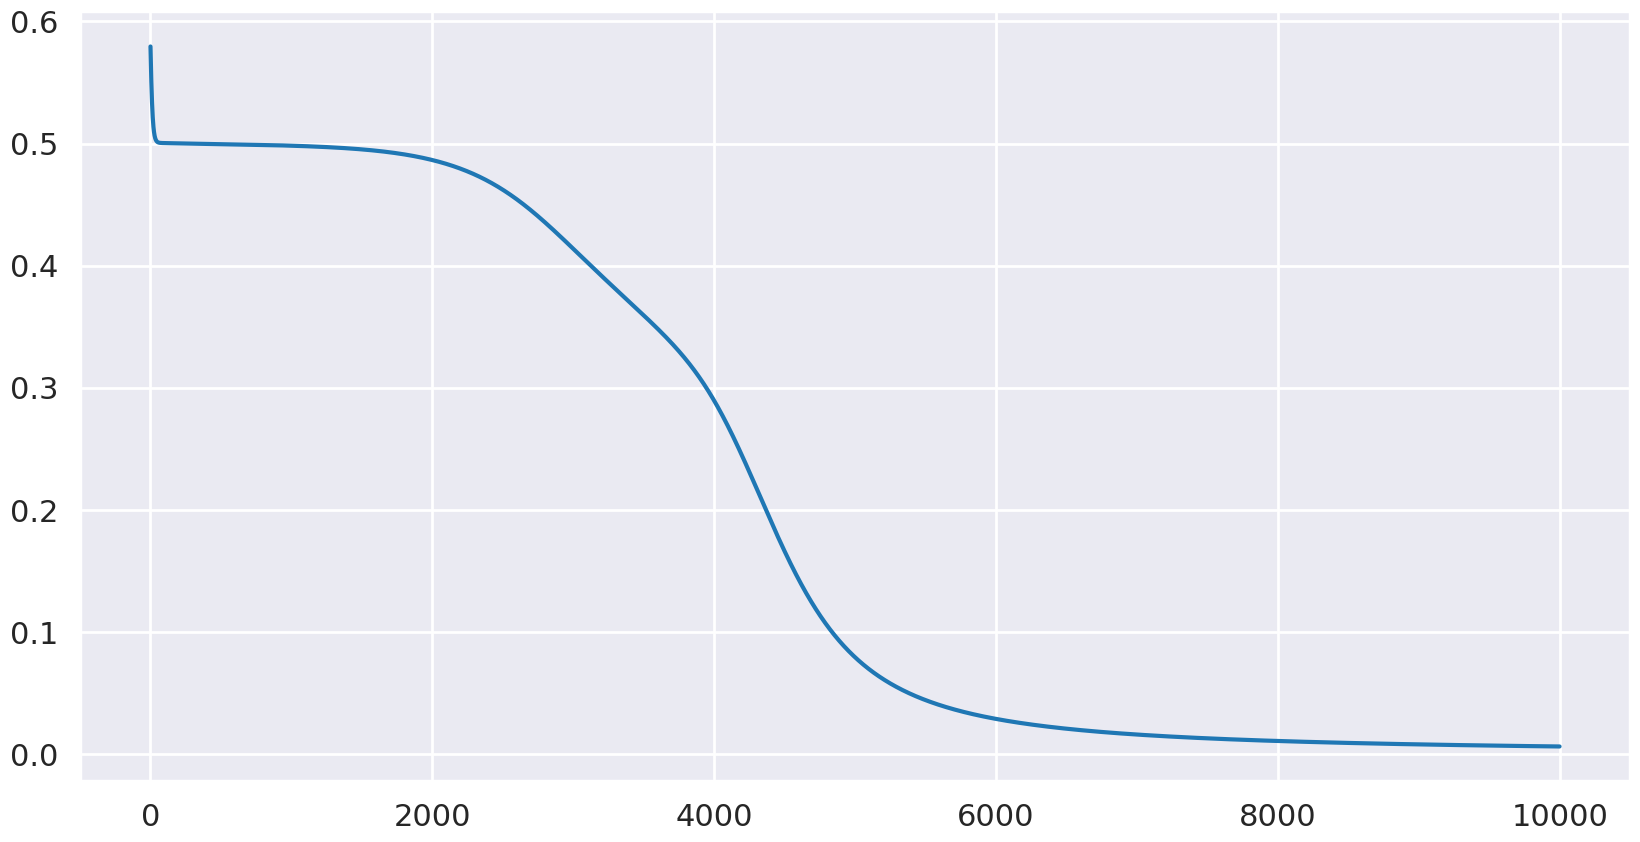

In [ ]:
plt.plot(mlp.losses)

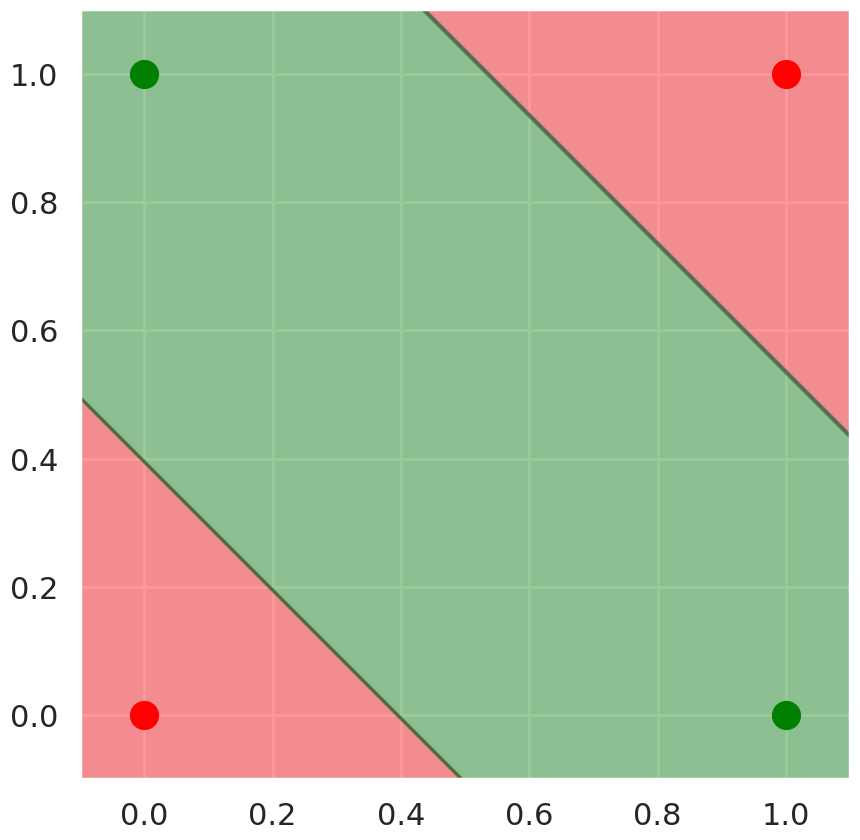

In [ ]:
mlp.plot()